# Laboratorio 8 — DuckDB
## Ejercicio 3: consultas directas sobre archivos Parquet

Este notebook explora los viajes Yellow Taxi y Green Taxi de 2026 con DuckDB. Las consultas leen los archivos Parquet directamente: no se crea ni se carga una tabla persistente. Las carpetas esperadas son `data/raw/yellow/2026/` y `data/raw/green/2026/`.

**Cobertura del corte analizado:** enero–agosto de 2026, 16 archivos. Los resultados registrados en las celdas Markdown se midieron el 6 de octubre de 2026; cambiarán cuando la TLC publique meses nuevos y se vuelvan a descargar. Ejecute las celdas de código para obtener resultados actualizados.

### Preparación

DuckDB está incluido en el ambiente del laboratorio. El siguiente bloque encuentra la raíz del proyecto tanto si el kernel inicia en `/workspace` como si inicia en `notebooks/`. En VS Code o Jupyter fuera de Docker, ejecute el notebook con el directorio del repositorio como raíz.

In [20]:
from pathlib import Path

import duckdb
import pandas as pd
from IPython.display import display

candidatos_raiz = (Path.cwd(), *Path.cwd().parents)
raiz_proyecto = next(
    (ruta for ruta in candidatos_raiz if (ruta / "data" / "raw").is_dir()),
    None,
)
if raiz_proyecto is None:
    raise FileNotFoundError(
        "No se encontro data/raw. Inicie Jupyter desde la raiz del repositorio "
        "o configure el kernel para ejecutarse dentro del proyecto."
    )

yellow_glob = str(raiz_proyecto / "data" / "raw" / "yellow" / "2026" / "*.parquet")
green_glob = str(raiz_proyecto / "data" / "raw" / "green" / "2026" / "*.parquet")
todos_glob = str(raiz_proyecto / "data" / "raw" / "*" / "2026" / "*.parquet")
con = duckdb.connect(database=":memory:")

print(f"Raiz del proyecto: {raiz_proyecto}")
print(f"DuckDB: {duckdb.__version__}")

Raiz del proyecto: d:\duckdb
DuckDB: 1.5.5


## 3.1 — Cantidad de archivos disponibles

**Consulta:** contar los nombres de archivo que aparecen en los metadatos Parquet. **Objetivo:** verificar cuántos archivos componen el conjunto. **Fuente:** ambos directorios `data/raw/<tipo>/2026/`. **Resultado observado:** 16 archivos (ocho por tipo). **Decisión:** este corte cubre enero–agosto, no los doce meses del año; la TLC todavía no había publicado septiembre–diciembre.

In [8]:
consulta_archivos = f"""
SELECT count(DISTINCT file_name) AS archivos
FROM parquet_metadata('{todos_glob}')
"""
display(con.execute(consulta_archivos).df())

,archivos
0,16


## 3.2 — Cantidad de registros y distribución mensual

**Consulta y objetivo:** contar registros por tipo y total, y contrastar los totales con los conteos mensuales. **Fuente:** los Parquet Yellow y Green. El total combinado usa `union_by_name = true` porque ambos esquemas contienen nombres diferentes para sus columnas temporales. **Resultado observado:** 29,703,355 registros Yellow, 337,114 Green y 30,040,469 en total. La suma de los conteos mensuales coincide con el total de cada tipo. **Decisión:** conservar el análisis separado por taxi cuando se usan columnas específicas y unir por nombre solo para operaciones comunes.

In [9]:
consulta_registros = f"""
SELECT 'yellow' AS tipo, count(*) AS registros
FROM read_parquet('{yellow_glob}')
UNION ALL
SELECT 'green', count(*)
FROM read_parquet('{green_glob}')
UNION ALL
SELECT 'total', count(*)
FROM read_parquet('{todos_glob}', union_by_name = true)
"""
display(con.execute(consulta_registros).df())

consulta_mensual = f"""
SELECT
    CASE WHEN filename LIKE '%yellow%' THEN 'yellow' ELSE 'green' END AS tipo,
    regexp_extract(filename, '2026-([0-9]{{2}})[.]parquet', 1) AS mes,
    count(*) AS registros
FROM read_parquet('{todos_glob}', union_by_name = true, filename = true)
GROUP BY tipo, mes
ORDER BY tipo, mes
"""
registros_mensuales = con.execute(consulta_mensual).df()
display(registros_mensuales.pivot(index="mes", columns="tipo", values="registros"))

,tipo,registros
0,yellow,29703355
1,green,337114
2,total,30040469


tipo,green,yellow
mes,,
01,40272,3724889
02,37373,3399866
03,44208,3952451
04,44238,3831240
05,44921,4090836
06,44163,3837248
07,41252,3530109
08,40687,3336716


## 3.3 y 3.4 — Columnas y tipos de datos

**Consultas:** `DESCRIBE` sobre los archivos de cada taxi por separado. **Objetivo:** obtener los nombres y tipos que DuckDB infiere del esquema Parquet. **Fuente:** los archivos mensuales de cada tipo. **Resultado observado:** 20 columnas Yellow y 21 Green; DuckDB indica que todas pueden contener nulos. Los tipos comunes incluyen `VendorID` (`INTEGER`), fechas (`TIMESTAMP`), `passenger_count` y `RatecodeID` (`BIGINT`), `trip_distance` y montos (`DOUBLE`), y `store_and_fwd_flag` (`VARCHAR`). **Decisión:** mantener los esquemas separados y no renombrar columnas de origen durante la exploración.

In [10]:
esquema_yellow = con.execute(
    f"DESCRIBE SELECT * FROM read_parquet('{yellow_glob}')"
).df()
esquema_green = con.execute(
    f"DESCRIBE SELECT * FROM read_parquet('{green_glob}')"
).df()

print(f"Yellow: {len(esquema_yellow)} columnas")
display(esquema_yellow[["column_name", "column_type", "null"]])
print(f"Green: {len(esquema_green)} columnas")
display(esquema_green[["column_name", "column_type", "null"]])

Yellow: 20 columnas


,column_name,column_type,null
0,VendorID,INTEGER,YES
1,tpep_pickup_datetime,TIMESTAMP,YES
2,tpep_dropoff_datetime,TIMESTAMP,YES
3,passenger_count,BIGINT,YES
4,trip_distance,DOUBLE,YES
5,RatecodeID,BIGINT,YES
6,store_and_fwd_flag,VARCHAR,YES
7,PULocationID,INTEGER,YES
8,DOLocationID,INTEGER,YES
9,payment_type,BIGINT,YES


Green: 21 columnas


,column_name,column_type,null
0,VendorID,INTEGER,YES
1,lpep_pickup_datetime,TIMESTAMP,YES
2,lpep_dropoff_datetime,TIMESTAMP,YES
3,store_and_fwd_flag,VARCHAR,YES
4,RatecodeID,BIGINT,YES
5,PULocationID,INTEGER,YES
6,DOLocationID,INTEGER,YES
7,passenger_count,BIGINT,YES
8,trip_distance,DOUBLE,YES
9,fare_amount,DOUBLE,YES


Los nombres de las columnas temporales distinguen los tipos: Yellow usa `tpep_pickup_datetime` y `tpep_dropoff_datetime`; Green usa `lpep_pickup_datetime` y `lpep_dropoff_datetime`. Yellow contiene `Airport_fee`, mientras Green contiene `ehail_fee` y `trip_type`; Green también incluye `cbd_congestion_fee`. Esto confirma que no se debe asumir que ambos esquemas son idénticos.

## 3.5 — Muestra de registros

**Consulta:** seleccionar tres filas por taxi con `LIMIT 3`. **Objetivo:** inspeccionar registros reales y verificar la legibilidad de campos importantes. **Fuente:** los Parquet Yellow y Green. **Resultado observado:** la primera fila Yellow tiene recogida `2026-01-01 00:54:04`, entrega `00:59:37`, distancia `0.97`, tarifa `7.20` y total `15.86`; la primera fila Green tiene recogida `2026-01-01 00:27:58`, entrega `00:55:16`, distancia `6.20`, tarifa `31.70` y total `45.20`. **Decisión:** usar las columnas `tpep_*` o `lpep_*` correspondientes. La muestra es para inspección, no es aleatoria ni sirve por sí sola para inferencia estadística.

In [11]:
muestra_yellow = f"""
SELECT VendorID, tpep_pickup_datetime, tpep_dropoff_datetime,
       passenger_count, trip_distance, fare_amount, total_amount
FROM read_parquet('{yellow_glob}')
LIMIT 3
"""
muestra_green = f"""
SELECT VendorID, lpep_pickup_datetime, lpep_dropoff_datetime,
       passenger_count, trip_distance, fare_amount, total_amount
FROM read_parquet('{green_glob}')
LIMIT 3
"""
display(con.execute(muestra_yellow).df())
display(con.execute(muestra_green).df())

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,total_amount
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1,0.97,7.2,15.86
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0,0.90,7.9,13.65
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0,1.40,10.7,18.95


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,total_amount
0,1,2026-01-01 00:27:58,2026-01-01 00:55:16,2,6.20,31.7,45.2
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,5,5.36,50.0,61.2
2,1,2026-01-01 00:23:45,2026-01-01 00:45:03,4,10.60,41.5,46.0


## 3.6 — Revisión inicial de calidad

**Consulta:** contar valores nulos y casos potencialmente atípicos: pasajeros en cero, distancia cero o negativa, tarifas y totales negativos, recogidas fuera de 2026, entrega anterior a recogida y duración superior a 24 horas. **Objetivo:** identificar aspectos que investigar antes de limpiar o analizar. **Fuente:** todos los archivos de cada tipo, revisados por separado. **Resultados observados:**

| Indicador | Yellow (29,703,355 filas) | Green (337,114 filas) |
|---|---:|---:|
| Recogida/entrega nula | 0 / 0 | 0 / 0 |
| `passenger_count` nulo | 7,716,688 | 48,775 |
| `passenger_count = 0` | 91,359 | 4,527 |
| `trip_distance = 0` | 952,231 | 12,212 |
| `trip_distance < 0` | 0 | 0 |
| `fare_amount < 0` | 157,364 | 999 |
| `total_amount < 0` | 161,835 | 1,023 |
| Recogida fuera de 2026 | 17 | 14 |
| Entrega anterior a recogida | 10 | 5 |
| Duración mayor a 24 horas | 263 | 4 |

**Decisión:** no se eliminan filas en esta inspección. Nulos y ceros de pasajeros, distancia cero, cargos negativos y duraciones extremas necesitan reglas de limpieza basadas en el contexto. Los cargos negativos podrían representar ajustes o reembolsos. Las recogidas fuera del año también se deben revisar antes de definir el periodo analítico. No se observaron fechas de recogida o entrega nulas ni distancias negativas en este corte.

In [12]:
def consulta_calidad(glob: str, prefijo_fecha: str, tipo: str) -> str:
    """Construye métricas de calidad usando las columnas temporales del taxi."""
    pickup = f"{prefijo_fecha}_pickup_datetime"
    dropoff = f"{prefijo_fecha}_dropoff_datetime"
    return f"""
    SELECT
        '{tipo}' AS tipo,
        count(*) AS registros,
        countif({pickup} IS NULL) AS pickup_nulo,
        countif({dropoff} IS NULL) AS dropoff_nulo,
        countif(passenger_count IS NULL) AS pasajeros_nulo,
        countif(passenger_count = 0) AS pasajeros_cero,
        countif(trip_distance = 0) AS distancia_cero,
        countif(trip_distance < 0) AS distancia_negativa,
        countif(fare_amount < 0) AS tarifa_negativa,
        countif(total_amount < 0) AS total_negativo,
        countif(year({pickup}) <> 2026) AS pickup_fuera_de_2026,
        countif({dropoff} < {pickup}) AS dropoff_antes_de_pickup,
        countif(date_diff('minute', {pickup}, {dropoff}) > 1440)
            AS duracion_mayor_a_un_dia
    FROM read_parquet('{glob}')
    """

calidad_yellow = con.execute(
    consulta_calidad(yellow_glob, "tpep", "yellow")
).df()
calidad_green = con.execute(
    consulta_calidad(green_glob, "lpep", "green")
).df()
display(pd.concat([calidad_yellow, calidad_green], ignore_index=True).set_index("tipo").T)

tipo,yellow,green
registros,29703355.0,337114.0
pickup_nulo,0.0,0.0
dropoff_nulo,0.0,0.0
pasajeros_nulo,7716688.0,48775.0
pasajeros_cero,91359.0,4527.0
distancia_cero,952231.0,12212.0
distancia_negativa,0.0,0.0
tarifa_negativa,157364.0,999.0
total_negativo,161835.0,1023.0
pickup_fuera_de_2026,17.0,14.0


## 3.7 y 3.8 — Consultas, fuentes y trazabilidad

Las celdas anteriores incluyen las consultas empleadas para los conteos, esquemas, muestras y métricas de calidad. Cada sección identifica su objetivo, fuente, resultado del corte observado y decisión. Las fuentes son los archivos en `data/raw/yellow/2026/*.parquet` y `data/raw/green/2026/*.parquet`; la consulta combinada lee ambos patrones con `union_by_name = true`. Todas las consultas leen los archivos directamente y no crean tablas persistentes.

## 3.9 — ¿Qué significa consultar Parquet directamente?

DuckDB usa `read_parquet` para leer las columnas y filas directamente de los archivos al ejecutar una consulta, sin importar primero el conjunto completo a una tabla de base de datos. Esta estrategia evita una etapa de importación y una copia adicional, permite pedir solo las columnas necesarias y facilita procesar varios meses mediante patrones de archivos. Parquet es columnar, por lo que las consultas que seleccionan pocas columnas pueden evitar leer las demás. `union_by_name` permite combinar datos por nombre de columna cuando los esquemas difieren o faltan campos.

La lectura directa resulta práctica para explorar volúmenes grandes y añadir nuevos archivos sin rehacer una importación. Si se repiten consultas costosas o se necesitan transformaciones persistentes, puede ser conveniente materializar resultados después; no fue necesario para este ejercicio.

## Ejercicio 4 — Análisis exploratorio con DuckDB

### 4.1 Preguntas analíticas

Se preguntará cómo varía el volumen por mes, día de semana y hora; qué diferencias hay entre Yellow y Green en distancia, duración, tarifa y total; qué categorías de pago y propinas se observan; y qué valores extremos o inconsistencias requieren revisión. Estas preguntas son pertinentes porque cada archivo representa un mes de viajes y contiene tiempos, distancias, importes y campos de pago. Se comparan distribuciones, sin atribuir causalidad. Las consultas leen directamente los Parquet y respetan los nombres temporales propios de cada taxi (`tpep_*` y `lpep_*`).

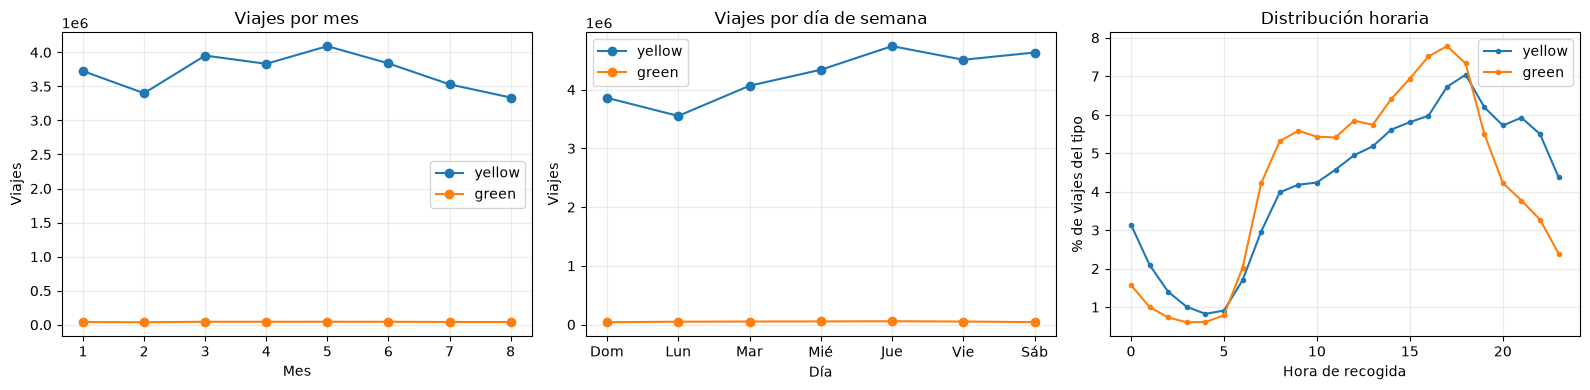

Día con más viajes por tipo:


,tipo,dia_semana,viajes
4,green,4,55672
11,yellow,4,4741513


Hora con más viajes por tipo:


,tipo,hora,viajes
17,green,17,26234
42,yellow,18,2091003


In [13]:
import matplotlib.pyplot as plt

consulta_temporal = f"""
SELECT tipo, dia_semana, hora, count(*) AS viajes
FROM (
    SELECT 'yellow' AS tipo, dayofweek(tpep_pickup_datetime) AS dia_semana,
           hour(tpep_pickup_datetime) AS hora
    FROM read_parquet('{yellow_glob}')
    UNION ALL
    SELECT 'green', dayofweek(lpep_pickup_datetime), hour(lpep_pickup_datetime)
    FROM read_parquet('{green_glob}')
) viajes
GROUP BY tipo, dia_semana, hora
"""
temporal = con.execute(consulta_temporal).df()
dia_nombres = {0: "Dom", 1: "Lun", 2: "Mar", 3: "Mié", 4: "Jue", 5: "Vie", 6: "Sáb"}
viajes_dia = temporal.groupby(["tipo", "dia_semana"], as_index=False)["viajes"].sum()
viajes_hora = temporal.groupby(["tipo", "hora"], as_index=False)["viajes"].sum()
viajes_mes = registros_mensuales.copy()
viajes_mes["mes"] = viajes_mes["mes"].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for tipo in ("yellow", "green"):
    por_mes = viajes_mes[viajes_mes["tipo"] == tipo]
    por_dia = viajes_dia[viajes_dia["tipo"] == tipo].sort_values("dia_semana")
    por_hora = viajes_hora[viajes_hora["tipo"] == tipo].sort_values("hora")
    axes[0].plot(por_mes["mes"], por_mes["registros"], marker="o", label=tipo)
    axes[1].plot(por_dia["dia_semana"].map(dia_nombres), por_dia["viajes"], marker="o", label=tipo)
    total_tipo = por_hora["viajes"].sum()
    axes[2].plot(por_hora["hora"], 100 * por_hora["viajes"] / total_tipo, marker=".", label=tipo)

axes[0].set(title="Viajes por mes", xlabel="Mes", ylabel="Viajes")
axes[1].set(title="Viajes por día de semana", xlabel="Día", ylabel="Viajes")
axes[2].set(title="Distribución horaria", xlabel="Hora de recogida", ylabel="% de viajes del tipo")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
fig.tight_layout()
plt.show()

print("Día con más viajes por tipo:")
display(viajes_dia.loc[viajes_dia.groupby("tipo")["viajes"].idxmax()])
print("Hora con más viajes por tipo:")
display(viajes_hora.loc[viajes_hora.groupby("tipo")["viajes"].idxmax()])

**4.2–4.4 — Temporalidad. Consulta:** agrupar las recogidas por mes (desde el nombre de archivo), día de semana y hora. **Fuente:** todos los Parquet Yellow y Green. **Resultado observado:** el mes con más registros fue mayo para ambos tipos; Yellow tuvo su máximo horario a las 18:00 y Green a las 17:00. Jueves fue el día con más registros para ambos en este corte. **Interpretación/decisión:** comparar horas como porcentaje de los viajes del propio tipo, además de comparar conteos absolutos, porque Yellow tiene muchos más registros. Los conteos mensuales describen meses disponibles, no una tendencia anual completa; no inferir causas a partir de estos patrones.

In [14]:
consulta_caracteristicas = f"""
WITH viajes AS (
    SELECT 'yellow' AS tipo,
           date_diff('second', tpep_pickup_datetime, tpep_dropoff_datetime) / 60.0 AS duracion_min,
           trip_distance, fare_amount, total_amount, tip_amount
    FROM read_parquet('{yellow_glob}')
    UNION ALL
    SELECT 'green',
           date_diff('second', lpep_pickup_datetime, lpep_dropoff_datetime) / 60.0,
           trip_distance, fare_amount, total_amount, tip_amount
    FROM read_parquet('{green_glob}')
)
SELECT tipo, count(*) AS registros,
       round(avg(duracion_min) FILTER (WHERE duracion_min >= 0), 2) AS duracion_media_min,
       round(quantile_cont(duracion_min, 0.5) FILTER (WHERE duracion_min >= 0), 2) AS duracion_mediana_min,
       round(avg(trip_distance), 2) AS distancia_media_mi,
       round(quantile_cont(trip_distance, 0.5), 2) AS distancia_mediana_mi,
       round(avg(fare_amount), 2) AS tarifa_media,
       round(quantile_cont(fare_amount, 0.5), 2) AS tarifa_mediana,
       round(avg(total_amount), 2) AS total_medio,
       round(quantile_cont(total_amount, 0.5), 2) AS total_mediano,
       round(avg(tip_amount), 2) AS propina_media
FROM viajes
GROUP BY tipo ORDER BY tipo
"""
caracteristicas = con.execute(consulta_caracteristicas).df()
display(caracteristicas)

,tipo,registros,duracion_media_min,duracion_mediana_min,distancia_media_mi,distancia_mediana_mi,tarifa_media,tarifa_mediana,total_medio,total_mediano,propina_media
0,green,337114,20.80,13.07,13.35,2.07,17.01,13.5,25.49,20.46,2.62
1,yellow,29703355,17.66,13.93,5.55,1.86,21.26,15.6,30.07,23.58,2.83


**4.2–4.4 — Características del viaje y distribuciones. Consulta:** calcular medias y medianas de duración válida, distancia, tarifa, total y propina; complementar con percentiles 50, 90, 95, 99 y 99.9 de distancia y total. **Fuente:** los 16 archivos; la duración excluye únicamente filas con entrega anterior a recogida. **Resultado observado:** Green tiene mayor distancia media (13.35 mi vs. 5.55 mi), pero Yellow tiene mayor tarifa y total medios (21.26 y 30.07 vs. 17.01 y 25.49). Las medianas son menores que las medias para la mayoría de los importes. **Interpretación/decisión:** las medias superiores a medianas indican colas hacia valores grandes; reportar ambas medidas y percentiles, no resumir viajes típicos solo con medias. Distancia y tarifa no determinan por sí solas el total.

,tipo,distancia_millas_p50_p999,total_dolares_p50_p999
0,green,"[2.07, 7.39, 10.53, 17.77, 30.024599999998465]","[20.5, 45.1, 57.72, 97.2, 225.40059999998311]"
1,yellow,"[1.86, 8.5, 12.25, 19.47, 30.6]","[23.69, 55.02, 77.75, 105.75, 184.8]"


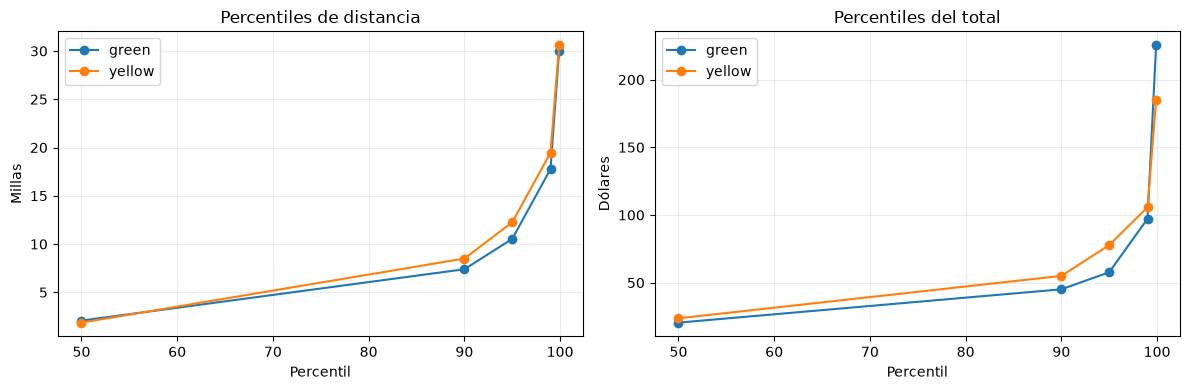

In [15]:
consulta_percentiles = f"""
SELECT tipo,
       quantile_cont(trip_distance, [0.5, 0.9, 0.95, 0.99, 0.999]) AS distancia_millas_p50_p999,
       quantile_cont(total_amount, [0.5, 0.9, 0.95, 0.99, 0.999]) AS total_dolares_p50_p999
FROM (
    SELECT 'yellow' AS tipo, trip_distance, total_amount FROM read_parquet('{yellow_glob}')
    UNION ALL
    SELECT 'green', trip_distance, total_amount FROM read_parquet('{green_glob}')
) datos
WHERE trip_distance >= 0 AND total_amount >= 0
GROUP BY tipo ORDER BY tipo
"""
percentiles = con.execute(consulta_percentiles).df()
display(percentiles)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for _, fila in percentiles.iterrows():
    axes[0].plot([50, 90, 95, 99, 99.9], fila["distancia_millas_p50_p999"], marker="o", label=fila["tipo"])
    axes[1].plot([50, 90, 95, 99, 99.9], fila["total_dolares_p50_p999"], marker="o", label=fila["tipo"])
axes[0].set(title="Percentiles de distancia", xlabel="Percentil", ylabel="Millas")
axes[1].set(title="Percentiles del total", xlabel="Percentil", ylabel="Dólares")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
fig.tight_layout()
plt.show()

## Variables relacionadas con el pago

**4.2–4.4 — Pregunta:** ¿qué proporción corresponde a cada `payment_type` y cómo varían total y propina registrados? **Consulta:** agrupar por código sin traducirlo a una etiqueta no verificada; calcular recuento, proporción, total medio, propina media y proporción de propinas positivas. **Fuente:** Yellow y Green por separado. **Resultado observado:** el código 1 es el más frecuente (63.77% Yellow, 65.25% Green); el código 2 es 9.12% y 19.55%, respectivamente. Yellow tiene 25.98% de código 0 y Green 14.47% nulo. **Decisión:** conservar el código 0 y los nulos como categorías distintas y revisar su semántica según el diccionario TLC antes de filtrarlos. Asociación observada no implica que el método de pago cause el monto de la propina.

,tipo,payment_type,viajes,porcentaje,total_medio,propina_media,porcentaje_propina_positiva
0,green,1,219980,65.25,25.84,3.84,90.39
1,green,2,65921,19.55,21.25,0.00,0.00
2,green,<NA>,48775,14.47,30.67,0.79,16.14
3,green,3,1688,0.50,6.09,0.00,0.95
4,green,4,750,0.22,2.59,0.00,0.13
5,yellow,1,18941008,63.77,30.18,4.28,91.08
6,yellow,0,7716688,25.98,32.57,0.40,8.14
7,yellow,2,2708031,9.12,25.17,0.00,0.01
8,yellow,4,239488,0.81,3.47,0.00,0.02
9,yellow,3,98138,0.33,12.67,0.00,0.03


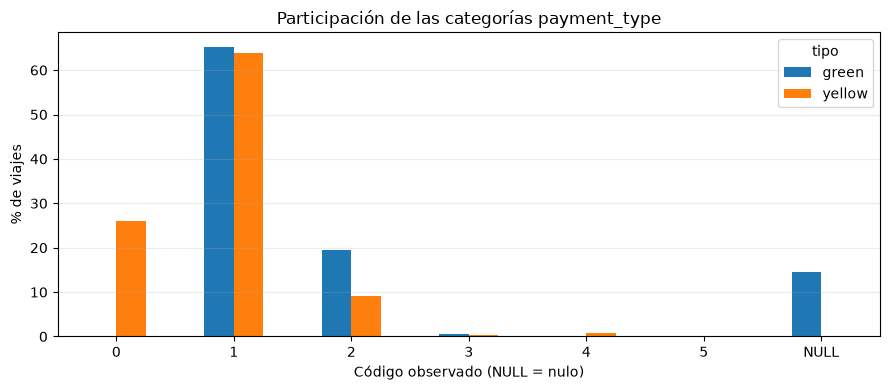

In [16]:
consulta_pagos = f"""
SELECT tipo, payment_type, count(*) AS viajes,
       round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo), 2) AS porcentaje,
       round(avg(total_amount), 2) AS total_medio,
       round(avg(tip_amount), 2) AS propina_media,
       round(100.0 * countif(tip_amount > 0) / count(*), 2) AS porcentaje_propina_positiva
FROM (
    SELECT 'yellow' AS tipo, payment_type, total_amount, tip_amount FROM read_parquet('{yellow_glob}')
    UNION ALL
    SELECT 'green', payment_type, total_amount, tip_amount FROM read_parquet('{green_glob}')
) pagos
GROUP BY tipo, payment_type
ORDER BY tipo, viajes DESC
"""
pagos = con.execute(consulta_pagos).df()
display(pagos)

pagos_grafico = pagos.copy()
pagos_grafico["categoria"] = pagos_grafico["payment_type"].astype("Int64").astype("string").fillna("NULL")
fig, ax = plt.subplots(figsize=(9, 4))
pagos_pivot = pagos_grafico.pivot(index="categoria", columns="tipo", values="porcentaje").fillna(0)
pagos_pivot.plot(kind="bar", ax=ax)
ax.set(title="Participación de las categorías payment_type", xlabel="Código observado (NULL = nulo)", ylabel="% de viajes")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Valores atípicos e inconsistencias

**4.2–4.4 — Pregunta:** ¿qué tan larga es la cola de las distribuciones y cuántos viajes superan umbrales de revisión? **Consulta:** calcular percentiles altos y contar distancia mayor de 100 millas, total mayor de 1,000 dólares, duración mayor de 24 horas, entrega anterior a recogida y montos negativos. Estos umbrales son banderas exploratorias, no reglas definitivas de invalidez. **Fuente:** todos los archivos por tipo. **Resultado observado:** la distancia p99.9 es aproximadamente 30.6 mi Yellow y 30.0 mi Green; el total p99.9 es 184.80 y 225.40 dólares. Los viajes sobre 100 millas y 1,000 dólares son escasos frente al volumen total. **Decisión:** investigar los casos antes de excluirlos; pueden representar viajes excepcionales, ajustes o problemas en datos.

In [17]:
consulta_atipicos = f"""
WITH viajes AS (
    SELECT 'yellow' AS tipo, tpep_pickup_datetime AS pickup, tpep_dropoff_datetime AS dropoff,
           trip_distance, fare_amount, total_amount
    FROM read_parquet('{yellow_glob}')
    UNION ALL
    SELECT 'green', lpep_pickup_datetime, lpep_dropoff_datetime,
           trip_distance, fare_amount, total_amount
    FROM read_parquet('{green_glob}')
)
SELECT tipo, count(*) AS registros,
       countif(trip_distance > 100) AS distancia_mayor_100_millas,
       countif(total_amount > 1000) AS total_mayor_1000_dolares,
       countif(date_diff('minute', pickup, dropoff) > 1440) AS duracion_mayor_24h,
       countif(dropoff < pickup) AS entrega_antes_recogida,
       countif(fare_amount < 0) AS tarifa_negativa,
       countif(total_amount < 0) AS total_negativo
FROM viajes GROUP BY tipo ORDER BY tipo
"""
atipicos = con.execute(consulta_atipicos).df()
display(atipicos)

,tipo,registros,distancia_mayor_100_millas,total_mayor_1000_dolares,duracion_mayor_24h,entrega_antes_recogida,tarifa_negativa,total_negativo
0,green,337114,72.0,1.0,4.0,5.0,999.0,1023.0
1,yellow,29703355,1223.0,49.0,263.0,10.0,157364.0,161835.0


## 4.5 — Hallazgos principales

1. **Patrones temporales similares en los máximos observados:** jueves concentra más recogidas que los demás días tanto para Yellow (4,741,513) como para Green (55,672); la hora pico es 18:00 para Yellow (2,091,003 viajes) y 17:00 para Green (26,234). Mayo tiene el mayor conteo mensual en ambos tipos. Los datos disponibles solo cubren enero–agosto.
2. **Los viajes Green son más largos, pero sus montos centrales son menores:** la distancia media Green es 13.35 millas frente a 5.55 Yellow, mientras que la tarifa media es 17.01 frente a 21.26 dólares y el total medio es 25.49 frente a 30.07. Las diferencias entre medias y medianas reflejan distribuciones asimétricas y aconsejan comparar percentiles.
3. **Pago codificado y datos de pago ausentes requieren atención:** `payment_type=1` es la categoría modal (63.77% Yellow, 65.25% Green). El 25.98% de Yellow aparece como código 0 y el 14.47% de Green tiene código nulo; no deben combinarse sin consultar el diccionario TLC.
4. **Hay colas largas y anomalías de calidad de distinta naturaleza:** existen montos negativos (161,835 Yellow; 1,023 Green), recogidas fuera de 2026 (17 y 14) y entregas anteriores a recogidas (10 y 5). También hay viajes muy largos; los umbrales se usan para inspección, no para eliminar filas automáticamente.

Estos hallazgos son descriptivos del corte de datos analizado y no demuestran causas. Antes de limpiar se debe revisar la documentación TLC para los códigos de pago y cargos negativos, y acordar filtros según el objetivo del análisis.

## Ejercicio 5 — Incorporación de los datos de 2024

### 5.1–5.5 Descarga, conservación y verificación

El descargador acepta años seleccionados y los separa en `data/raw/<tipo>/<año>/`. Se añadió `2024` sin cambiar ni reemplazar los archivos existentes de `2026`; los archivos no vacíos se omiten cuando ya existen. Ejecuté `docker compose exec -T lab python scripts/download_data.py --year 2024`: se descargaron 24 archivos (12 por tipo), sin omisiones ni fallos. Después, repetir `--year 2024` omitió los 24 archivos. El directorio 2026 conservó sus 16 archivos; la ejecución para Yellow 2026 omitió los ocho ya descargados. Los archivos temporales `.part` se eliminan al completar correctamente una descarga.

### 5.6 Comprobación conjunta con DuckDB

**Pregunta:** ¿DuckDB puede leer conjuntamente ambos años y distinguir sus registros por año y tipo? **Consulta:** contar archivos con `parquet_metadata` y contar filas de todos los archivos agrupándolas mediante el año del nombre de archivo y el nombre de la ruta. `union_by_name = true` acomoda columnas que faltan o difieren. **Fuente:** `data/raw/{yellow,green}/{2024,2026}/*.parquet`. **Resultado observado:** 40 archivos Parquet legibles y 71,870,407 registros; Yellow 2024: 41,169,720; Green 2024: 660,218; Yellow 2026: 29,703,355; Green 2026: 337,114. **Decisión:** mantener el año y tipo como dimensiones de consulta; no concatenar filas sin conservar estas etiquetas.

In [19]:
todos_los_anios_glob = str(raiz_proyecto / "data" / "raw" / "*" / "*" / "*.parquet")

consulta_archivos_anios = f"""
SELECT count(DISTINCT file_name) AS archivos
FROM parquet_metadata('{todos_los_anios_glob}')
"""
consulta_registros_anios = f"""
SELECT
    regexp_extract(filename, '(202[46])-[0-9]{{2}}[.]parquet', 1) AS anio,
    CASE WHEN filename LIKE '%yellow%' THEN 'yellow' ELSE 'green' END AS tipo_taxi,
    count(*) AS registros
FROM read_parquet('{todos_los_anios_glob}', union_by_name = true, filename = true)
GROUP BY anio, tipo_taxi
ORDER BY anio, tipo_taxi
"""
consulta_total_anios = f"""
SELECT count(*) AS registros_totales
FROM read_parquet('{todos_los_anios_glob}', union_by_name = true)
"""

display(con.execute(consulta_archivos_anios).df())
registros_por_anio_taxi = con.execute(consulta_registros_anios).df()
display(registros_por_anio_taxi)
display(con.execute(consulta_total_anios).df())

print("Columnas de la lectura conjunta (union_by_name):")
display(con.execute(
    f"DESCRIBE SELECT * FROM read_parquet('{todos_los_anios_glob}', union_by_name = true)"
).df()[["column_name", "column_type"]])

,archivos
0,40


,anio,tipo_taxi,registros
0,2024,green,660218
1,2024,yellow,41169720
2,2026,green,337114
3,2026,yellow,29703355


,registros_totales
0,71870407


Columnas de la lectura conjunta (union_by_name):


,column_name,column_type
0,VendorID,INTEGER
1,lpep_pickup_datetime,TIMESTAMP
2,lpep_dropoff_datetime,TIMESTAMP
3,store_and_fwd_flag,VARCHAR
4,RatecodeID,BIGINT
5,PULocationID,INTEGER
6,DOLocationID,INTEGER
7,passenger_count,BIGINT
8,trip_distance,DOUBLE
9,fare_amount,DOUBLE


### 5.7 ¿Hay que modificar las consultas anteriores?

Las consultas del Ejercicio 3 y 4 están deliberadamente presentadas como el análisis del corte 2026. Para repetirlas solo sobre ese año no requieren cambios. Para incluir 2024 se deben ampliar los patrones de entrada de `data/raw/<tipo>/2026/*.parquet` a `data/raw/<tipo>/*/*.parquet` (y el patrón combinado a `data/raw/*/*/*.parquet`) y, para comparaciones, agrupar por año extraído del nombre del archivo. Las columnas temporales `tpep_*`/`lpep_*` siguen siendo diferentes entre tipos; se conserva `UNION ALL` explícito por tipo o `union_by_name = true` para lecturas combinadas. Filtros rígidos como `year(pickup) <> 2026` deben convertirse en validaciones de año basadas en el nombre del archivo o ajustarse al año seleccionado: de otro modo marcarían todas las filas de 2024 como fuera del periodo.

### 5.8–5.9 Consultas de validación y diseño extensible

Las consultas de validación completas están en la celda anterior: contar archivos con `parquet_metadata`, agrupar registros del `read_parquet` conjunto por año y tipo, contar el total combinado y consultar el esquema unido con `DESCRIBE`. La evidencia obtenida fue 40 archivos (24 de 2024, 16 de 2026), 71,870,407 filas y registros presentes para las cuatro combinaciones de año/tipo.

La incorporación no exige reconstruir el flujo porque los datos se guardan por tipo y año, los nombres de archivos son sistemáticos, el descargador recibe años como argumento, omite archivos locales existentes y verifica descargas antes de renombrarlas. Las consultas DuckDB leen patrones de archivos directamente en lugar de depender de una tabla con rutas fijas. Para nuevos años se amplía la lista admitida por el descargador y se conserva el patrón `*` del análisis; solo deben revisarse filtros temporales o cambios futuros de esquema.

## Ejercicio 6 — Parquet versus tablas DuckDB

### 6.1–6.4 Diseño del benchmark

Se comparan consultas directas a Parquet con las mismas consultas sobre una tabla DuckDB materializada. La tabla incluye una columna `anio` y `tipo_taxi` derivadas del nombre del archivo. `union_by_name = true` alinea las columnas que cambian entre taxis o años. Se prueban dos escalas: solo 2026 (16 archivos) y ambos años 2024+2026 (40 archivos). Para cada escala, las consultas representativas cuentan viajes por año/tipo, agrupan viajes por mes, resumen distancia/duración/montos y comparan pagos.

El tiempo de creación de la tabla se registra aparte, no se mezcla con los tiempos de consulta. Cada consulta se ejecuta una vez para calentar el motor/sistema de archivos y luego se cronometra tres veces; se reporta la mediana y el rango. Ambas estrategias usan el mismo proceso y se alterna su orden. Este es un benchmark de lectura con caché caliente; los resultados dependen del equipo, memoria, disco y versión de DuckDB, y no representan una medición universal de lectura fría.

In [21]:
from time import perf_counter

ruta_db_benchmark = raiz_proyecto / "data" / "processed" / "ejercicio_6_benchmark.duckdb"
ruta_db_benchmark.parent.mkdir(parents=True, exist_ok=True)
ruta_parquet_benchmark = todos_los_anios_glob.replace("\\", "/")
benchmark_con = duckdb.connect(str(ruta_db_benchmark))

inicio_materializacion = perf_counter()
benchmark_con.execute(f"""
CREATE OR REPLACE TABLE viajes AS
SELECT
    CAST(regexp_extract(filename, '(202[46])-[0-9]{{2}}[.]parquet', 1) AS INTEGER) AS anio,
    CASE WHEN filename LIKE '%yellow%' THEN 'yellow' ELSE 'green' END AS tipo_taxi,
    * EXCLUDE (filename)
FROM read_parquet('{ruta_parquet_benchmark}', union_by_name = true, filename = true)
""")
benchmark_con.execute("ANALYZE viajes")
tiempo_materializacion_s = perf_counter() - inicio_materializacion
filas_materializadas = benchmark_con.execute("SELECT count(*) FROM viajes").fetchone()[0]
tamano_db_bytes = ruta_db_benchmark.stat().st_size

resumen_materializacion = pd.DataFrame([{
    "tabla": "viajes",
    "filas": filas_materializadas,
    "tiempo_creacion_s": round(tiempo_materializacion_s, 2),
    "tamano_db_GiB": round(tamano_db_bytes / 1024**3, 3),
    "ruta": str(ruta_db_benchmark.relative_to(raiz_proyecto)),
}])
display(resumen_materializacion)

,tabla,filas,tiempo_creacion_s,tamano_db_GiB,ruta
0,viajes,71870407,62.62,1.87,data\processed\ejercicio_6_benchmark.duckdb


La tabla se guarda en `data/processed/ejercicio_6_benchmark.duckdb`, directorio excluido de Git. Reejecutar la celda vuelve a crear `viajes` desde los archivos Parquet locales, útil si se incorporan datos nuevos; requiere espacio libre para el archivo DuckDB. La construcción y `ANALYZE` pueden tardar y forman parte del costo de preparación, que debe considerarse al elegir materialización.

### 6.3, 6.7 y 6.8 Consultas representativas y tabla de resultados

Las consultas comparadas son: **Q1 conteo**, filas por año y tipo; **Q2 temporal**, viajes por mes; **Q3 características**, distancia media/mediana, duración mediana, tarifa y total medios; **Q4 pagos**, recuento y porcentaje por tipo de pago. Las mismas dimensiones, filtros y expresiones se aplican a ambas fuentes. Los datos se filtran antes de agrupar para comparar 2026 y 2024+2026 sobre las mismas cantidades de entrada.

In [ ]:
glob_2026 = (raiz_proyecto / "data" / "raw" / "*" / "2026" / "*.parquet").as_posix()
glob_todos = (raiz_proyecto / "data" / "raw" / "*" / "*" / "*.parquet").as_posix()
escala_glob = {"2026 (16 archivos)": glob_2026, "2024+2026 (40 archivos)": glob_todos}
escala_anios = {"2026 (16 archivos)": (2026,), "2024+2026 (40 archivos)": (2024, 2026)}
repeticiones_benchmark = 3

def consultas_benchmark(estrategia: str, escala: str) -> dict[str, str]:
    """Devuelve SQL equivalente sobre Parquet o sobre la tabla materializada."""
    anios_sql = ", ".join(map(str, escala_anios[escala]))
    if estrategia == "Parquet directo":
        origen = f"read_parquet('{escala_glob[escala]}', union_by_name = true, filename = true)"
        anio_expr = "CAST(regexp_extract(filename, '(202[46])-[0-9]{2}[.]parquet', 1) AS INTEGER)"
        taxi_expr = "CASE WHEN filename LIKE '%yellow%' THEN 'yellow' ELSE 'green' END"
        filtro = f"{anio_expr} IN ({anios_sql})"
    else:
        origen = "viajes"
        anio_expr = "anio"
        taxi_expr = "tipo_taxi"
        filtro = f"anio IN ({anios_sql})"

    pickup = "coalesce(tpep_pickup_datetime, lpep_pickup_datetime)"
    dropoff = "coalesce(tpep_dropoff_datetime, lpep_dropoff_datetime)"
    return {
        "Q1 Conteo por año/tipo": f"""
            SELECT {anio_expr} AS anio, {taxi_expr} AS tipo_taxi, count(*) AS viajes
            FROM {origen} WHERE {filtro}
            GROUP BY anio, tipo_taxi ORDER BY anio, tipo_taxi
        """,
        "Q2 Viajes por mes": f"""
            SELECT {anio_expr} AS anio, {taxi_expr} AS tipo_taxi,
                   month({pickup}) AS mes, count(*) AS viajes
            FROM {origen} WHERE {filtro}
            GROUP BY anio, tipo_taxi, mes ORDER BY anio, tipo_taxi, mes
        """,
        "Q3 Características del viaje": f"""
            SELECT {anio_expr} AS anio, {taxi_expr} AS tipo_taxi,
                   round(avg(trip_distance), 3) AS distancia_media_mi,
                   round(median(trip_distance), 3) AS distancia_mediana_mi,
                   round(median(date_diff('second', {pickup}, {dropoff}) / 60.0)
                         FILTER (WHERE {dropoff} >= {pickup}), 3) AS duracion_mediana_min,
                   round(avg(fare_amount), 3) AS tarifa_media,
                   round(avg(total_amount), 3) AS total_medio
            FROM {origen} WHERE {filtro}
            GROUP BY anio, tipo_taxi ORDER BY anio, tipo_taxi
        """,
        "Q4 Distribución de pago": f"""
            SELECT {anio_expr} AS anio, {taxi_expr} AS tipo_taxi, payment_type,
                   count(*) AS viajes,
                   round(100.0 * count(*) / sum(count(*)) OVER
                         (PARTITION BY {anio_expr}, {taxi_expr}), 2) AS porcentaje,
                   round(avg(tip_amount), 3) AS propina_media
            FROM {origen} WHERE {filtro}
            GROUP BY anio, tipo_taxi, payment_type
            ORDER BY anio, tipo_taxi, payment_type NULLS LAST
        """,
    }

consultas_por_prueba = {
    (estrategia, escala): consultas_benchmark(estrategia, escala)
    for escala in escala_glob
    for estrategia in ("Parquet directo", "Tabla DuckDB")
}

# Calentamiento no cronometrado y comprobación de resultados equivalentes.
for escala in escala_glob:
    for nombre_consulta in consultas_por_prueba[("Parquet directo", escala)]:
        sql_parquet = consultas_por_prueba[("Parquet directo", escala)][nombre_consulta]
        sql_tabla = consultas_por_prueba[("Tabla DuckDB", escala)][nombre_consulta]
        resultado_parquet = con.execute(sql_parquet).df()
        resultado_tabla = benchmark_con.execute(sql_tabla).df()
        pd.testing.assert_frame_equal(
            resultado_parquet, resultado_tabla,
            check_dtype=False, check_exact=False, rtol=1e-6, atol=1e-6,
        )

mediciones = []
for escala in escala_glob:
    for nombre_consulta in consultas_por_prueba[("Parquet directo", escala)]:
        tiempos_por_estrategia = {"Parquet directo": [], "Tabla DuckDB": []}
        filas_por_estrategia = {}
        for repeticion in range(repeticiones_benchmark):
            orden = ["Parquet directo", "Tabla DuckDB"]
            if repeticion % 2:
                orden.reverse()
            for estrategia in orden:
                sql = consultas_por_prueba[(estrategia, escala)][nombre_consulta]
                cursor = con if estrategia == "Parquet directo" else benchmark_con
                inicio = perf_counter()
                resultado = cursor.execute(sql).fetchall()
                tiempos_por_estrategia[estrategia].append(perf_counter() - inicio)
                filas_por_estrategia[estrategia] = len(resultado)

        for estrategia, tiempos in tiempos_por_estrategia.items():
            mediciones.append({
                "escala": escala,
                "consulta": nombre_consulta,
                "estrategia": estrategia,
                "filas_resultado": filas_por_estrategia[estrategia],
                "mediana_s": pd.Series(tiempos).median(),
                "min_s": min(tiempos),
                "max_s": max(tiempos),
            })

benchmark_resultados = pd.DataFrame(mediciones)
benchmark_comparacion = benchmark_resultados.pivot(
    index=["escala", "consulta"], columns="estrategia", values="mediana_s"
).reset_index()
benchmark_comparacion["aceleracion_tabla_vs_parquet"] = (
    benchmark_comparacion["Parquet directo"] / benchmark_comparacion["Tabla DuckDB"]
).round(2)
display(benchmark_resultados.round(3))
display(benchmark_comparacion.round(3))

### 6.9–6.10 Análisis e interpretación

Se validó que las cuatro consultas devolvieran los mismos resultados con Parquet y con la tabla. Esta tabla resume las medianas de tres repeticiones, el rango mínimo–máximo en segundos y la aceleración `mediana Parquet / mediana tabla` (mayor que 1 favorece la tabla):

| Escala | Consulta | Parquet (mediana; mín–máx) | Tabla DuckDB (mediana; mín–máx) | Aceleración tabla |
|---|---|---:|---:|---:|
| 2026, 16 archivos | Q1 Conteo por año/tipo | 0.095; 0.090–0.100 | 0.205; 0.198–0.222 | 0.46x |
| 2026, 16 archivos | Q2 Viajes por mes | 0.809; 0.793–0.842 | 0.408; 0.403–0.421 | 1.98x |
| 2026, 16 archivos | Q3 Características del viaje | 6.431; 6.181–6.439 | 4.984; 4.383–6.151 | 1.29x |
| 2026, 16 archivos | Q4 Distribución de pago | 0.851; 0.821–0.900 | 0.679; 0.662–0.698 | 1.25x |
| 2024+2026, 40 archivos | Q1 Conteo por año/tipo | 0.200; 0.181–0.204 | 0.661; 0.646–0.664 | 0.30x |
| 2024+2026, 40 archivos | Q2 Viajes por mes | 1.747; 1.730–1.781 | 1.185; 1.157–1.198 | 1.47x |
| 2024+2026, 40 archivos | Q3 Características del viaje | 10.688; 10.599–10.746 | 11.300; 10.987–11.759 | 0.95x |
| 2024+2026, 40 archivos | Q4 Distribución de pago | 1.682; 1.670–1.772 | 1.811; 1.790–1.883 | 0.93x |

En este equipo la tabla fue más rápida para las agrupaciones mensuales en ambas escalas (1.98x y 1.47x) y para Q3/Q4 con 2026 solamente. El conteo por año/tipo favoreció Parquet (la tabla tardó aproximadamente 2.17x y 3.31x más). Con ambos años, Q3 y Q4 favorecieron levemente a Parquet. Los tiempos aumentaron al pasar de 16 a 40 archivos, sobre todo en Q3; materializar no elimina el costo de agregar decenas de millones de filas.

La materialización de 71,870,407 filas tardó 62.62 s y ocupó aproximadamente 1.87 GiB, costos aparte de las consultas. En este benchmark de caché caliente no hay una ventaja única: Parquet conviene para lecturas ocasionales y almacenamiento/intercambio; una tabla puede convenir si las consultas repetidas que se ejecutan se benefician lo suficiente como para compensar la creación, el almacenamiento y la actualización. Los resultados dependen del hardware, DuckDB y estado de caché y no representan lectura fría.